In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [17]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)

        # for i, row in enumerate(df):
        #     df.iloc[i, 1] = len(df["URL"].iloc[i])

        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [18]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0):
    df = pd.read_csv(filename)
    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [19]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [20]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [21]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

    clf = LogisticRegression(C=5, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
        X_train, y_train
    )
    return clf

In [22]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean.csv",
    [
        "URL",
        "Domain",
        "TLD",
        "Title",
        "DomainTitleMatchScore",
        "IsResponsive",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasSocialNet",
        "HasSubmitButton",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "HasCopyrightInfo",
        "NoOfImage",
        "NoOfCSS",
        "URLSimilarityIndex",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [23]:
X, y, df = load_data("../data/uci_phishing_url_dataset_clean.csv", "IsLegit", 100000)

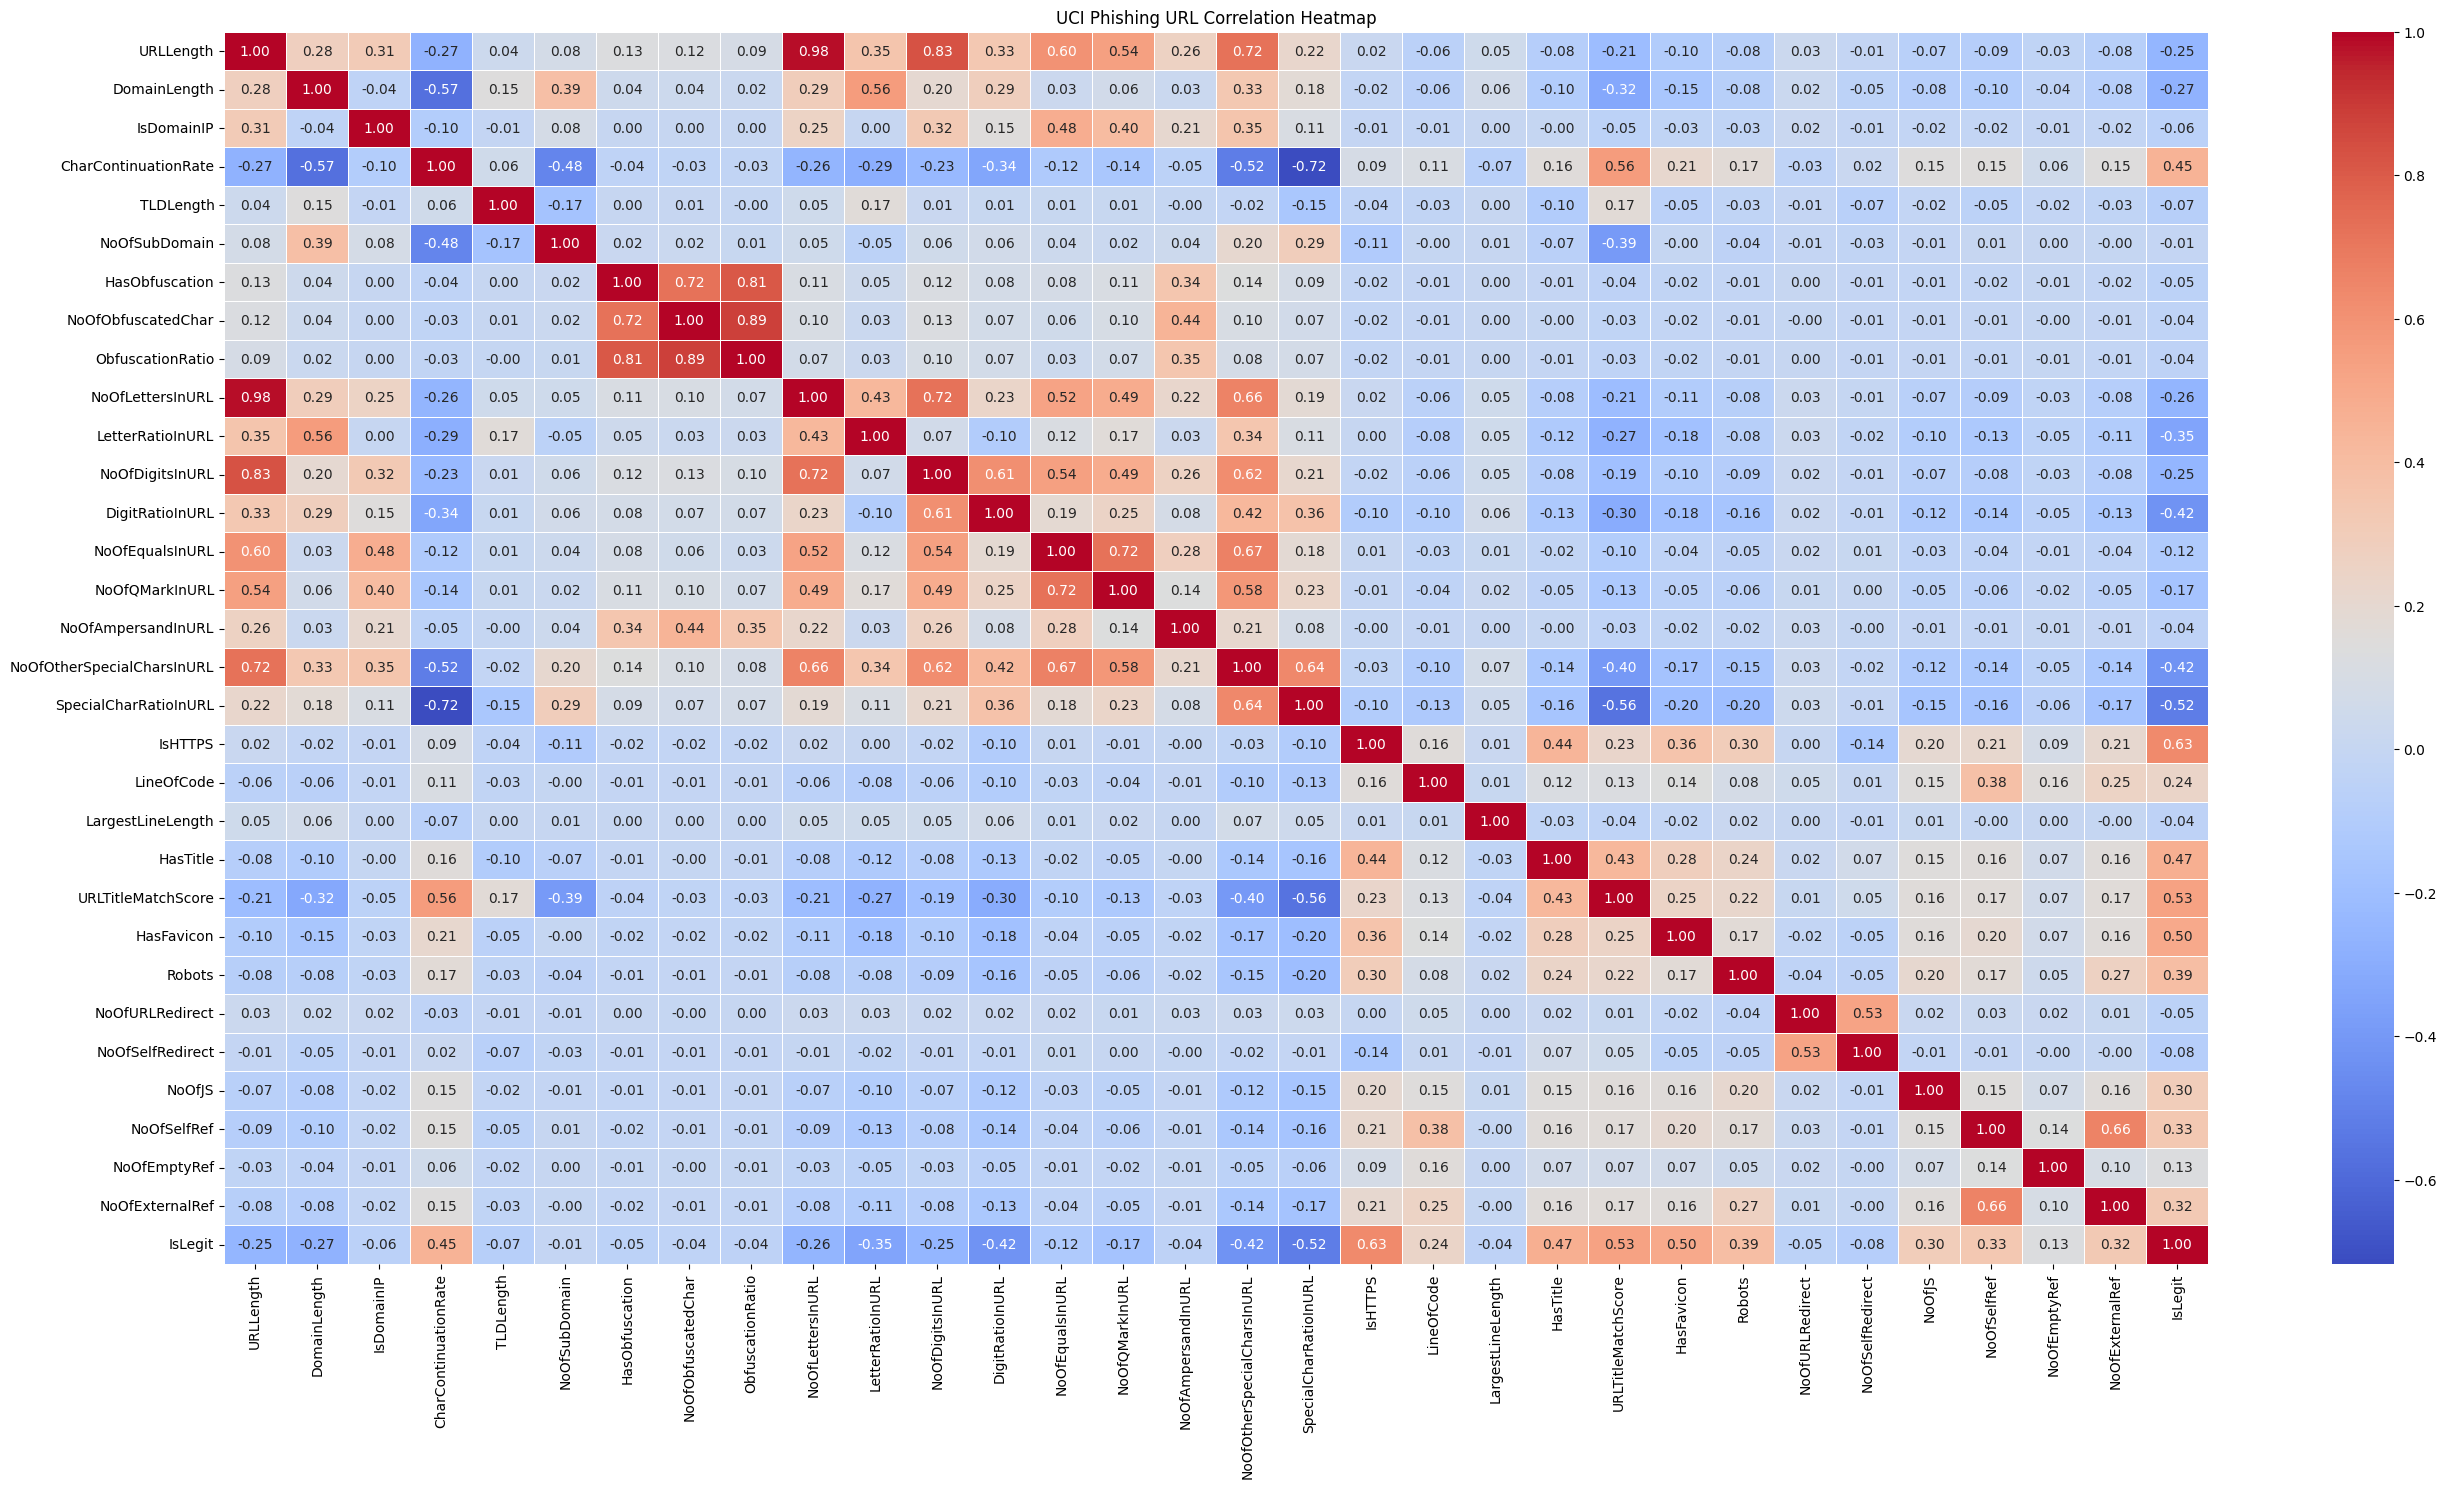

In [24]:
show_corr_matrix(df, "../outputs/uci_phishing_url_corr_matrix.png")

In [25]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
clf = logistic_regression_model_training(X_train, X_test, y_train, y_test)

working on 0 with C value: 0.0001


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


KeyboardInterrupt: 

In [26]:
joblib.dump(
    {"features": X_train.columns.tolist(), "model": clf}, "../models/logit_model.pkl"
)

['../models/logit_model.pkl']

In [15]:
X_train

,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,...,HasTitle,URLTitleMatchScore,HasFavicon,Robots,NoOfURLRedirect,NoOfSelfRedirect,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
2606,27,20,0,0.846154,2,2,0,0,0.0,13,...,1,0.0,0,0,0,0,12,51,0,17
57228,21,14,0,0.571429,2,2,0,0,0.0,7,...,1,0.0,0,1,0,0,5,22,1,27
8382,22,15,0,0.625000,2,2,0,0,0.0,8,...,1,0.0,0,0,0,0,10,140,6,13
60281,20,13,0,1.000000,3,1,0,0,0.0,7,...,1,100.0,1,0,0,0,11,35,10,28
48432,29,22,0,1.000000,3,1,0,0,0.0,16,...,1,0.0,1,0,0,0,6,39,0,143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21243,26,20,0,0.545455,4,2,0,0,0.0,13,...,1,0.0,0,0,0,0,0,0,0,0
45891,27,20,0,0.583333,3,1,0,0,0.0,13,...,1,100.0,1,0,0,0,72,69,1,3
42613,27,19,0,0.666667,3,0,0,0,0.0,17,...,1,100.0,0,0,0,0,0,0,0,0
43567,29,22,0,0.533333,2,1,0,0,0.0,15,...,1,0.0,1,0,0,0,18,141,7,156


In [27]:
model_dump = joblib.load("../models/logit_model.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_new, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-3.70519692e+00  8.02626948e+00 -2.82952850e-03  3.86113126e-03
  -1.03750332e+00  5.38017532e-01 -6.82850504e-04 -8.14631576e-04
  -2.17784711e-05 -4.55512027e+00 -1.07358579e-01 -6.70410106e+00
  -1.96499227e-01 -6.40062712e-02 -5.59173622e-02 -4.85786950e-03
  -5.50860366e+00 -2.05510770e-01  8.23761692e+00  2.51923159e-02
  -1.03611828e-03  4.24750858e-02  4.84397209e-03  1.41941327e+00
   2.62149735e-01 -1.20039514e+00 -4.23943340e-01  6.08296561e-01
   1.72475648e-01  3.68969877e-01  1.11128987e-01]]
Accuracy: 0.9993151441511101
